# Palace Directional Coupler Simulation - Wave Ports

This notebook mirrors the geometry in [meep_dc.ipynb](meep_dc.ipynb), but configures a Palace driven simulation with waveport boundary conditions.

MEEP-specific features (for example FDTD PML/animation details) are omitted.

### Load the same directional coupler geometry

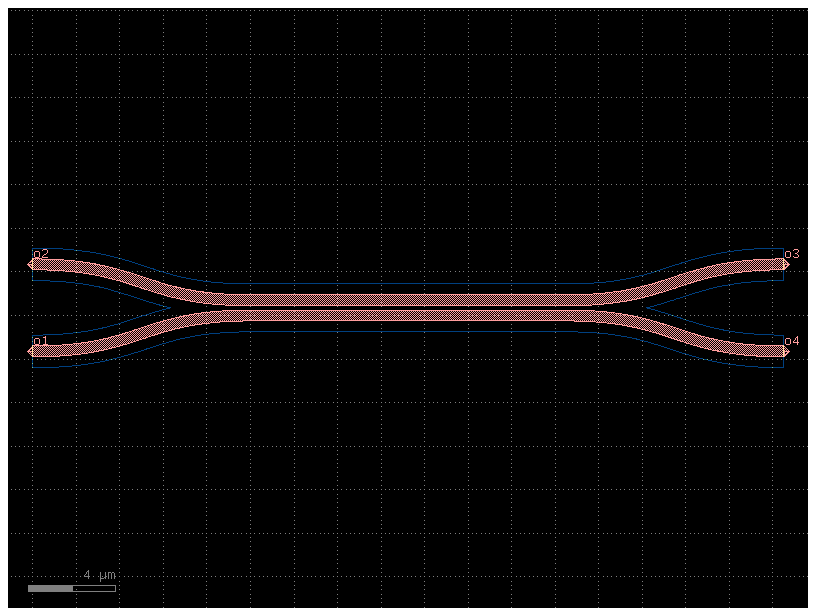

In [1]:
from pathlib import Path

import gdsfactory.component as gfc
from ubcpdk import PDK, cells

# Use a workspace-local temp path for layer preview artifacts.
gds_tmp = Path.cwd() / ".gdsfactory_tmp"
gds_tmp.mkdir(parents=True, exist_ok=True)
gfc.GDSDIR_TEMP = gds_tmp

PDK.activate()

c = cells.coupler()

cc = c.copy()
cc.draw_ports()
cc

### Configure Palace driven simulation with waveports

In [2]:
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-dc-waveport")
sim.set_geometry(c)

sim.set_stack(
    substrate_thickness=2.0,
    add_oxide_dielectric=False,
    add_passivation_dielectric=False,
)

# Use direct sparse solve backend.
sim.set_numerical(
    solver_type="MUMPS",
    max_iterations=1,
    tolerance=1e-8,
)

for i, port in enumerate(c.ports):
    sim.add_wave_port(
        str(port.name),
        layer="core",
        z_margin=1.5,
        lateral_margin=1.5,
        max_size=False,
        mode=1,
        excited=(i == 0),
    )

# Around 1.55 um (~193.5 THz).
sim.set_driven(fmin=190e12, fmax=200e12, num_points=21)

print(sim.validate_config())

Validation: PASSED


In [3]:
import gdsfactory as gf

active = gf.get_active_pdk()
print("Active PDK:", active.name)

stack = sim._resolve_stack()
print("Stack layers:")
for name, layer in stack.layers.items():
    print(
        f"  - {name}: type={layer.layer_type}, material={layer.material}, "
        f"gds={tuple(layer.gds_layer)}, z=({layer.zmin}, {layer.zmax})"
    )

print("\nMaterial properties (selected):")
for key in ("si", "sio2", "SiO2", "air"):
    if key in stack.materials:
        print(f"  - {key}: {stack.materials[key]}")

print("\nDielectric regions:")
for d in stack.dielectrics:
    print(f"  - {d}")

Active PDK: ubcpdk
Stack layers:
  - box: type=dielectric, material=sio2, gds=(999, 0), z=(-3.0, 0.0)
  - clad: type=dielectric, material=sio2, gds=(999, 0), z=(0.0, 1.8000000000000003)
  - core: type=dielectric, material=si, gds=(1, 0), z=(0.0, 0.22)
  - core2: type=dielectric, material=si, gds=(31, 0), z=(0.0, 0.22)
  - heater: type=conductor, material=TiN, gds=(11, 0), z=(1.1, 1.85)
  - metal2: type=conductor, material=Aluminum, gds=(12, 0), z=(1.8000000000000003, 2.5000000000000004)

Material properties (selected):
  - si: {'type': 'semiconductor', 'conductivity': 2.0, 'permittivity': 11.9, 'refractive_index': 3.47}
  - sio2: {'type': 'dielectric', 'permittivity': 4.1, 'loss_tangent': 0.0, 'refractive_index': 1.44}
  - SiO2: {'type': 'dielectric', 'permittivity': 4.1, 'loss_tangent': 0.0, 'refractive_index': 1.44}
  - air: {'type': 'dielectric', 'permittivity': 1.0, 'loss_tangent': 0.0, 'refractive_index': 1.0}

Dielectric regions:


### Generate mesh

In [4]:
sim.set_airbox(
    margin_x=0.0,
    margin_y=1.5,
    margin_above=0.5,
    margin_below=0.5,
)

# fmax=220 THz -> lambda0~1.36 um. In Si (n~3.45), lambda~0.395 um,
# so for >=5 points per wavelength use mesh size <=0.079 um.
sim.mesh(
    preset="fine",
    refined_mesh_size=0.05,
    max_mesh_size=0.25,
    fmax=220e12,
    curve_fit_mode="bspline",
    curve_fit_layers=["core", "core2"],
    curve_fit_tolerance_um=0.01,
    curve_fit_min_points=8,
    high_order_elements=True,
    high_order_order=2,
    high_order_optimize=True,
)

Mesh Summary
Dimensions: 34.5 x 7.5 x 6.5 µm
Nodes:      832,208
Elements:   668,884
----------------------------------------
Volumes (2):
  - core [1]
  - airbox [2]
Surfaces (6):
  - P1 [3]
  - P2 [4]
  - P3 [5]
  - P4 [6]
  - airbox__core [7]
  - airbox__None [8]
----------------------------------------
Mesh:   palace-sim-dc-waveport/palace.msh

In [5]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["airbox__None"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:34545/index.html?ui=P_0x7b097723c8f0_0&reconnect=auto" class="pyvi…

### Run simulation

In [6]:
for p in sim._last_mesh_result.port_info:
    print(
        f"{p['type']} P{p['portnumber']}: "
        f"z=({p['zmin']:.3f}, {p['zmax']:.3f}), "
        f"x=({p['xmin']:.3f}, {p['xmax']:.3f}), "
        f"y=({p['ymin']:.3f}, {p['ymax']:.3f})"
    )

waveport P1: z=(-1.500, 1.720), x=(-10.000, -10.000), y=(-3.400, 0.100)
waveport P2: z=(-1.500, 1.720), x=(-10.000, -10.000), y=(0.600, 4.100)
waveport P3: z=(-1.500, 1.720), x=(24.500, 24.500), y=(0.600, 4.100)
waveport P4: z=(-1.500, 1.720), x=(24.500, 24.500), y=(-3.400, 0.100)


In [7]:
import json
from pathlib import Path

# For photonic sims, bypass conductor-oriented mesh validation.
config_path = sim.write_config(photonic=True)
cfg = json.loads(Path(config_path).read_text())
print("Solver.Linear:", cfg["Solver"]["Linear"])

results = sim.run_local(num_processes=16, verbose=True)

Running Palace simulation in palace-sim-dc-waveport via Apptainer
Command: apptainer run /home/martin/Desktop/palace/Palace.sif -np 16 config.json
Processes: 16
>> /usr/lib64/mpich/bin/mpirun -n 16 /opt/palace/bin/palace-x86_64.bin config.json


Solver.Linear: {'Type': 'MUMPS', 'KSPType': 'GMRES', 'Tol': 1e-08, 'MaxIts': 1, 'MGMaxLevels': 1, 'EstimatorMaxIts': 0, 'EstimatorTol': 1e-06, 'DivFreeTol': 1e-06, 'DivFreeMaxIts': 0, 'PCMatReal': False, 'ComplexCoarseSolve': True}


_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/
--> Warning!
Output folder is not empty; program will overwrite content! (output/palace)
Git changeset ID: v0.14.0-305-g51d61b03
Running with 16 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked
Finished partitioning mesh into 16 subdomains
Characteristic length and time scales:
 L₀ = 3.450e-05 m, t₀ = 1.151e-04 ns
Mesh curvature order: 2
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-1.000e-05, -3.400e-06, -3.500e-06) m
 (Xmax, Ymax, Zmax) = (+2.450e-05, +4.100e-06, +3.000e-06) m
Parallel Mesh Stats:
                minimum     average     maximum       total
 vertices          6024        6799        7995      108785
 edges            43183       45168       48227      722695
 faces            73483       7507

### Plot S-parameters

In [8]:
results.plot_interactive()

Port mapping: Port 1: p1, Port 2: p2, Port 3: p3, Port 4: p4


In [9]:
results.plot_interactive(phase=True)

Port mapping: Port 1: p1, Port 2: p2, Port 3: p3, Port 4: p4
